## __Data Science: Capstone Part 2: Lightning Talk 2__

### Overview

On the **One** topic you have selected you would need to:
1. Refine your problem statement. for more info [ML-Framing-a-Data-Science-Problem]() **<--- will cover on Tuesday**
2. Create / Compile a data dictionary
3. Clean the data and Perform in-depth EDA (Insights + EDA for Modeling)
4. Outline proposed preprocessing/feature engineering and models

### Presentation Requirements (5 Minutes)
* Refined Problem Statement  (including Success Metrics)
* Potential Audience
* Goals & Objectives
    * Type of Models (e.g: Regression/Classification)
    * Number of models
    * Evaluation Metrics
* About the data (Data Dictionary and EDA for Modeling) - Keep this short 
* Progress report (Challenges & Next Steps)



___Note: EDA for Image based Topics___
* Classes (Target)
* Settings (Transformation)
* Data Limitations


# Adult Income Prediction
Data Source : https://www.kaggle.com/datasets/mosapabdelghany/adult-income-prediction-dataset

# Problem Statement

The Raw Issue: Workforce and career-development organizations often rely on broad strategies because they cannot identify which individuals are more likely to achieve higher income levels. This makes it difficult to provide targeted support and understand the factors associated with economic success.

The Structured Objective: We aim to classify individuals into "high income" (>50K/year) or "lower income" (≤50K/year) groups using demographic and employment characteristics such as education, occupation, age, working hours, and capital gains/losses. This model will help workforce analysts identify the key factors associated with higher income and support more targeted career-development strategies, achieving an F1-score ≥ 0.70 and ROC-AUC ≥ 0.85 for the high-income class.

## Objectives

The analysis and modeling will be guided by the following questions:

1. Which numerical and categorical features show the strongest relationships with income class?

2. How imbalanced is the target variable, and which evaluation metrics are most appropriate?

3. Which features require encoding, scaling, transformation, or further evaluation before modeling?

4. Which classification model provides the best F1-score and ROC-AUC for identifying individuals earning >$50K?

# Data Inspection

## Data Dictionary
| Column         | Type        | Description                  |
| -------------- | ----------- | ---------------------------- |
| age            | Numerical   | Age of individual            |
| workclass      | Categorical | Type of employment           |
| fnlwgt         | Numerical   | Census population weight     |
| education      | Categorical | Education level              |
| education.num  | Numerical   | Education level encoded      |
| marital.status | Categorical | Marital status               |
| occupation     | Categorical | Job type                     |
| relationship   | Categorical | Household relationship       |
| race           | Categorical | Race category                |
| sex            | Categorical | Gender                       |
| capital.gain   | Numerical   | Capital gains                |
| capital.loss   | Numerical   | Capital losses               |
| hours.per.week | Numerical   | Weekly working hours         |
| native.country | Categorical | Country of origin            |
| income         | Categorical | Income class (>50K or <=50K) |


In [1]:
# organize your imports in this cell
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from scipy.stats import chi2_contingency


## Data Overview
Load and inspect the dataset
- Source and format
- .head(), .info(), .describe(),…

In [2]:
df = pd.read_csv("adult.csv")
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [3]:
df.shape

(32561, 15)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.2 MB


In [5]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [6]:
df.dtypes

age               int64
workclass           str
fnlwgt            int64
education           str
education.num     int64
marital.status      str
occupation          str
relationship        str
race                str
sex                 str
capital.gain      int64
capital.loss      int64
hours.per.week    int64
native.country      str
income              str
dtype: object

In [7]:
df['income'].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [8]:
df['income'].value_counts(normalize=True) * 100

income
<=50K    75.919044
>50K     24.080956
Name: proportion, dtype: float64

# Data Cleaning
Handle missing values, outliers, and inconsistencies

In [9]:
df.duplicated().sum()

np.int64(24)

In [10]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

### Duplicate Treatment

24 exact duplicate rows were identified and removed.

This represents less than 0.1% of the dataset, so removing them has minimal impact on the dataset size while preventing repeated observations from influencing the analysis.

In [11]:
df = df.replace('?', np.nan)
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     582
income               0
dtype: int64

In [12]:
for col in ['workclass', 'occupation', 'native.country']:
    df[col] = df[col].fillna(df[col].mode()[0])


df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

### Missing Value Treatment

The dataset used '?' as a placeholder for missing values in:
- workclass
- occupation
- native.country

These placeholders were converted to NaN.

Because all three variables are categorical, missing values were filled using the mode (most frequent category) of each column.

After treatment, no missing values remained.

## Cleaning Summary

- 24 exact duplicate rows were removed.
- '?' placeholders were converted to missing values.
- Missing values in workclass, occupation, and native.country were treated using mode imputation.
- Numerical outliers were investigated rather than automatically removed.
- The cleaned dataset contains 32,537 observations.

# Exploratory Data Analysis (EDA)
Answer objectives using visual and statistical insights
- Trends, relationships, anomalies
- Outlier and missing values treatment
- Univariate, bivariate, or multivariate analysis
    - Histograms, box plots, bar charts
    - Correlation matrix for continuous columns (required if applicable)


In [13]:
numerical_features = df.select_dtypes(include='number').columns
numerical_features

Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='str')

In [14]:
len(numerical_features)

6

In [15]:
categorical_features = df.select_dtypes(exclude='number').columns
categorical_features

Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country', 'income'],
      dtype='str')

In [16]:
len(categorical_features)

9

In [17]:
df['income_binary'] = df['income'].map({'<=50K':0,'>50K':1})
df[['income','income_binary']].head()

,income,income_binary
0,<=50K,0
1,<=50K,0
2,<=50K,0
3,<=50K,0
4,<=50K,0


For correlation analysis only, the target was temporarily encoded as:

- <=50K = 0
- >50K = 1

In [18]:
corr = df.corr(numeric_only=True)
corr

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,income_binary
age,1.000000,-0.076447,0.036224,0.077676,0.057745,0.068515,0.234037
fnlwgt,-0.076447,1.000000,-0.043388,0.000429,-0.010260,-0.018898,-0.009502
education.num,0.036224,-0.043388,1.000000,0.122664,0.079892,0.148422,0.335272
capital.gain,0.077676,0.000429,0.122664,1.000000,-0.031639,0.078408,0.223336
capital.loss,0.057745,-0.010260,0.079892,-0.031639,1.000000,0.054229,0.150501
hours.per.week,0.068515,-0.018898,0.148422,0.078408,0.054229,1.000000,0.229658
income_binary,0.234037,-0.009502,0.335272,0.223336,0.150501,0.229658,1.000000


In [19]:
corr['income_binary'].sort_values(ascending=False)

income_binary     1.000000
education.num     0.335272
age               0.234037
hours.per.week    0.229658
capital.gain      0.223336
capital.loss      0.150501
fnlwgt           -0.009502
Name: income_binary, dtype: float64

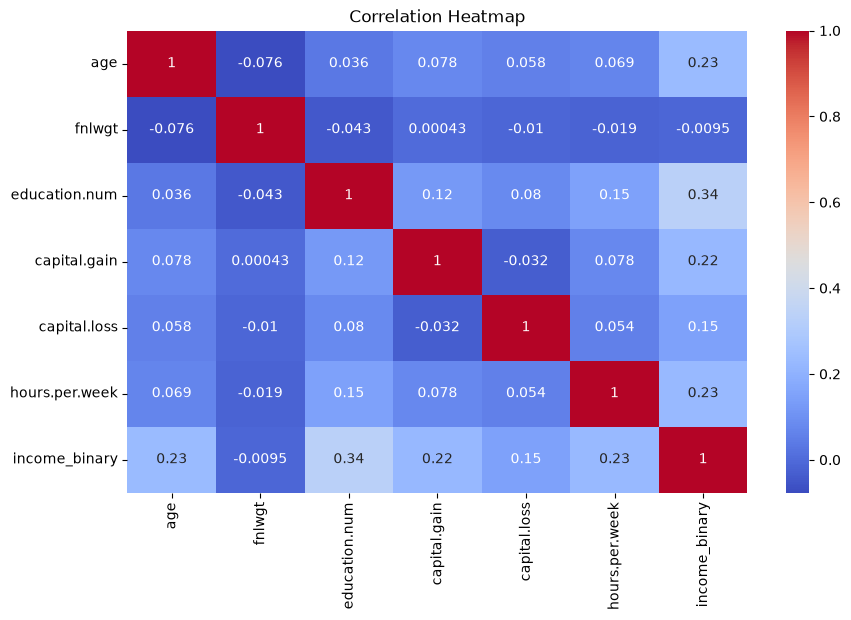

In [20]:
plt.figure(figsize=(10,6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

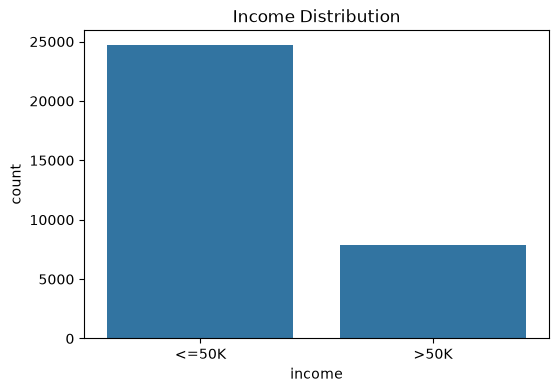

In [21]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='income'
)

plt.title("Income Distribution")

plt.show()

The target is moderately imbalanced:

- approximately 75.9% earn <=50K
- approximately 24.1% earn >50K

Therefore, accuracy alone may be misleading. F1-score and ROC-AUC will be emphasized during model evaluation.

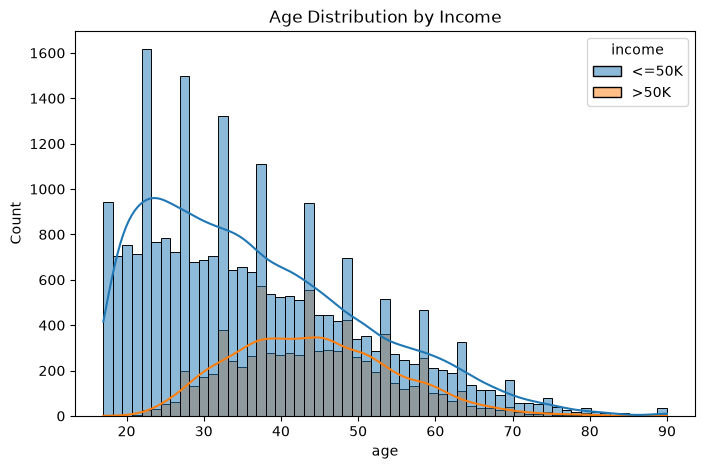

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='age',
    hue='income',
    kde=True
)

plt.title("Age Distribution by Income")

plt.show()

Higher-income observations are more concentrated among middle-aged individuals, particularly around the 35–55 age range.

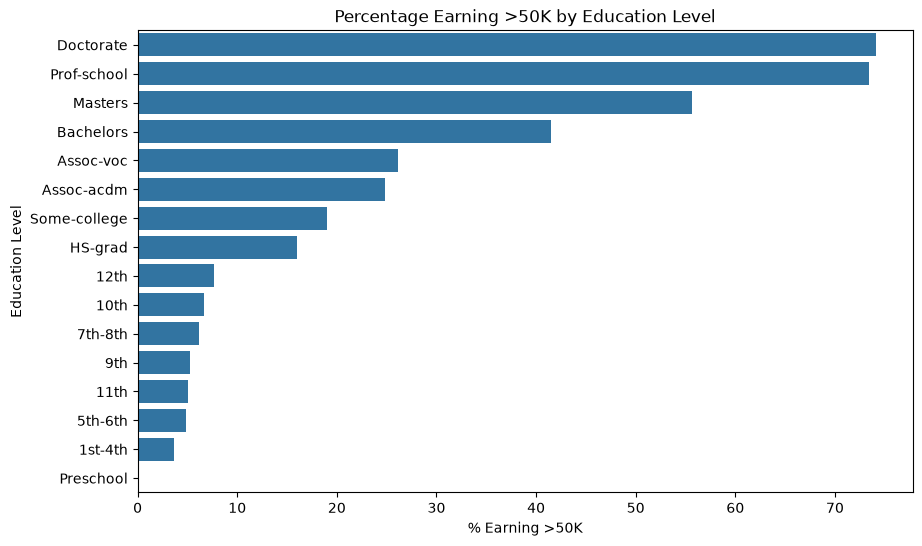

In [23]:
education_income = (
    pd.crosstab(
        df['education'],
        df['income'],
        normalize='index'
    )['>50K']
    .sort_values(ascending=False)
    * 100
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=education_income.values,
    y=education_income.index
)

plt.xlabel('% Earning >50K')
plt.ylabel('Education Level')
plt.title('Percentage Earning >50K by Education Level')

plt.show()

Advanced education levels such as Doctorate, Prof-school, and Masters show a substantially higher proportion of individuals earning >50K.

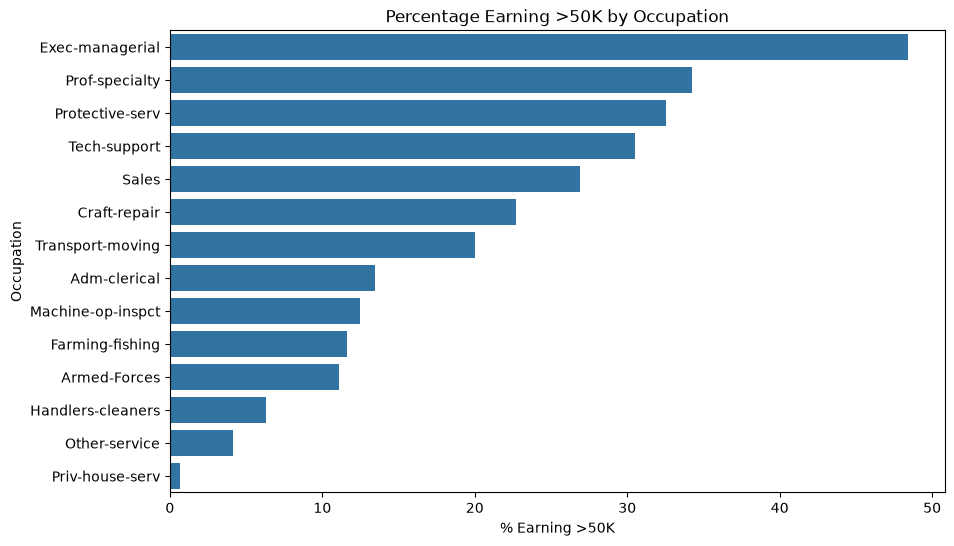

In [24]:
occupation_income = (
    pd.crosstab(
        df['occupation'],
        df['income'],
        normalize='index'
    )['>50K']
    .sort_values(ascending=False)
    * 100
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=occupation_income.values,
    y=occupation_income.index
)

plt.xlabel('% Earning >50K')
plt.ylabel('Occupation')
plt.title('Percentage Earning >50K by Occupation')

plt.show()

Exec-managerial and Prof-specialty occupations have some of the highest proportions of individuals earning >50K.

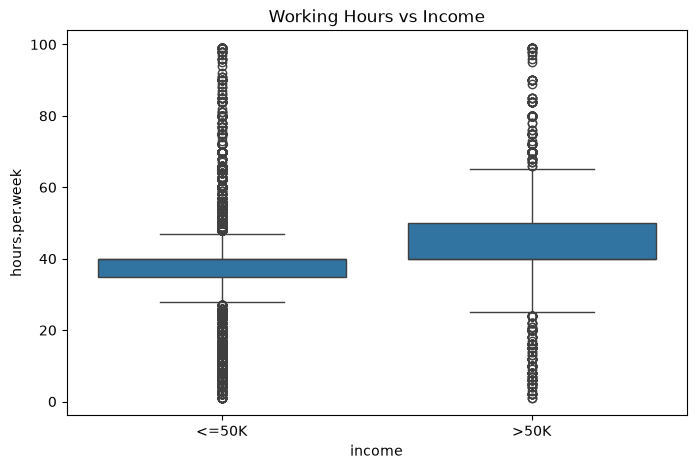

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='income',
    y='hours.per.week'
)

plt.title("Working Hours vs Income")

plt.show()

The >50K income group generally shows higher weekly working hours, although both income groups contain a wide range of values.

In [26]:
df[['age',
    'fnlwgt',
    'capital.gain',
    'capital.loss',
    'hours.per.week']].describe()

,age,fnlwgt,capital.gain,capital.loss,hours.per.week
count,32537.000000,3.253700e+04,32537.000000,32537.000000,32537.000000
mean,38.585549,1.897808e+05,1078.443741,87.368227,40.440329
std,13.637984,1.055565e+05,7387.957424,403.101833,12.346889
min,17.000000,1.228500e+04,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,0.000000,0.000000,40.000000
75%,48.000000,2.369930e+05,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,99999.000000,4356.000000,99.000000


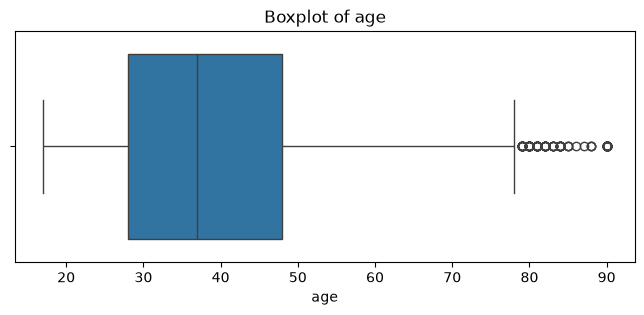

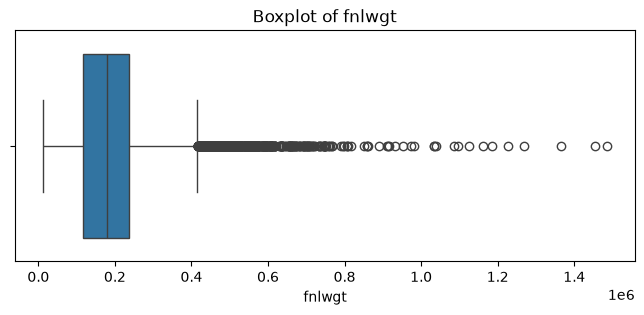

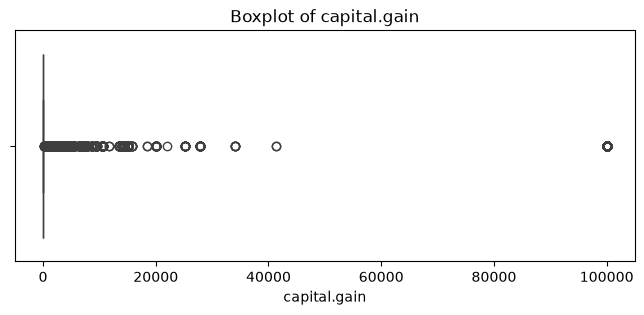

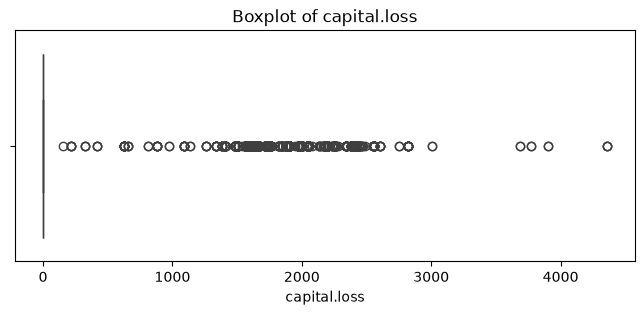

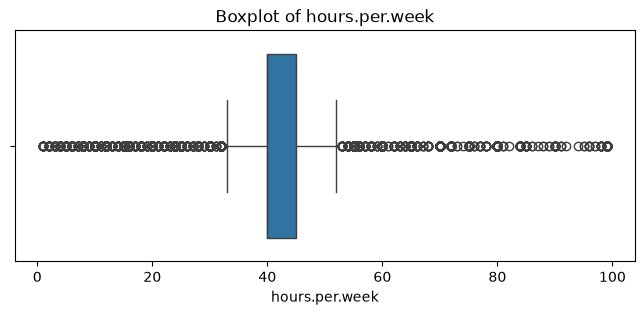

In [27]:
outlier_cols = [
    'age',
    'fnlwgt',
    'capital.gain',
    'capital.loss',
    'hours.per.week'
]

for col in outlier_cols:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

### Outlier Treatment

Several numerical variables contain extreme values, particularly:

- fnlwgt
- capital.gain
- capital.loss

These observations were retained because they appear to represent valid values rather than obvious data-entry errors.

The impact of highly skewed features can be evaluated further during modeling.

## Chi-Square Tests for Categorical Features

Chi-square tests are used to determine whether each categorical feature has a statistically significant association with income class.

In [28]:
categorical_cols = [
    'workclass',
    'education',
    'marital.status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native.country']

chi_results = []

for col in categorical_cols:
    contingency_table = pd.crosstab(
        df[col],
        df['income'] )

    chi2, p_value, dof, expected = chi2_contingency(
        contingency_table
    )

    chi_results.append({
        'Feature': col,
        'Chi-Square': chi2,
        'P-Value': p_value
    })

chi_results = pd.DataFrame(chi_results)

chi_results.sort_values(
    by='Chi-Square',
    ascending=False
)

,Feature,Chi-Square,P-Value
4,relationship,6692.098803,0.000000e+00
2,marital.status,6510.332127,0.000000e+00
1,education,4428.404688,0.000000e+00
3,occupation,3197.612778,0.000000e+00
6,sex,1516.539711,0.000000e+00
0,workclass,922.349848,7.156801e-195
5,race,330.943399,2.279787e-70
7,native.country,315.372099,1.762524e-44


All tested categorical variables show statistically significant associations with income at the 0.05 significance level.

However, because the dataset is large, statistical significance alone does not indicate the strength of the relationship. These results should therefore be interpreted together with the EDA visualizations.

# EDA Findings

### Target
- Income is a binary target: <=50K or >50K.
- Approximately 24% of observations belong to the >50K class, indicating moderate class imbalance.

### Numerical Features
- education.num has the strongest positive linear association with income among numerical variables.
- age and hours.per.week show moderate positive relationships with income.
- capital.gain also shows a meaningful positive relationship.
- fnlwgt has almost no linear association with the target.

### Categorical Features
- Higher education levels are associated with a larger percentage of >50K earners.
- Exec-managerial and Prof-specialty occupations show some of the highest proportions of >50K earners.
- Chi-square tests indicate statistically significant associations between the categorical variables and income.

### Outliers
- Heavy-tailed values exist in fnlwgt, capital.gain, and capital.loss.
- These observations were retained because they appear to represent valid variation rather than data errors.

### Modeling Implications
- Numerical features will require scaling for scale-sensitive models.
- Categorical features will require encoding.
- Class imbalance should be considered during evaluation.
- The usefulness of fnlwgt should be evaluated rather than assumed.
- education and education.num contain overlapping information and should be reviewed for redundancy.

# Data Preprocessing & Feature Engineering
Transforming, encoding, standardization and preparing features
- **You only need to outline your approach here. No need to execute**


The following preprocessing steps are planned for the modeling phase:

1. **Train/Test Split**
   - 80% training data
   - 20% testing data
   - Stratify by income to preserve the class distribution

2. **Numerical Features**
   - Apply StandardScaler where appropriate.

3. **Categorical Features**
   - Apply OneHotEncoder with `handle_unknown='ignore'`.

4. **Missing Values**
   - In the final modeling pipeline, categorical imputation can be fitted using the training data only to avoid data leakage.

5. **Feature Selection**
   - Evaluate model performance with and without `fnlwgt`.
   - Review redundancy between `education` and `education.num`.

6. **Class Imbalance**
   - Use F1-score and ROC-AUC as key evaluation metrics.
   - Evaluate class weighting for suitable models.

7. **Pipeline**
   - Use a ColumnTransformer and Pipeline during the modeling phase to ensure consistent preprocessing.

# Modelling Approach
What are the models you are planning to build for your capstone.
- **You only need to outline your approach here. No need to execute**


This project is a binary classification problem.

Four classification models are planned:

### 1. Logistic Regression
An interpretable baseline model that will establish initial performance.

### 2. Decision Tree
A non-linear model capable of identifying threshold-based relationships between features.

### 3. Random Forest
An ensemble of decision trees designed to reduce variance and improve generalization.

### 4. Gradient Boosting
An ensemble model that sequentially improves predictions and is a strong candidate for tabular classification.

## Evaluation Metrics

Models will be compared using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

**Primary metric:** F1-score for the >50K class  
**Secondary metric:** ROC-AUC

A simple majority-class baseline will also be considered so that the trained models can be compared against a naive prediction strategy.

During the modeling phase, cross-validation and hyperparameter tuning will be used before final evaluation on the held-out test set.

# Data Limitations & Challenges

- The dataset contains demographic variables such as race and sex, which require careful interpretation because they may reflect historical social and economic inequalities.

- The dataset represents a specific population and time period, so results may not generalize perfectly to current or different populations.

- The >$50K threshold is specific to this dataset and should not be interpreted as a universal definition of high income.

- The target class is moderately imbalanced, with only around 24% of observations belonging to the >50K category.

- `education` and `education.num` contain overlapping information.

- `fnlwgt` is a census sampling weight rather than a direct individual characteristic, so its usefulness for prediction should be evaluated.

# Next Steps

1. Finalize the preprocessing pipeline.
2. Split the data into stratified training and testing sets.
3. Train the four candidate classification models.
4. Apply cross-validation and hyperparameter tuning.
5. Evaluate models using F1-score and ROC-AUC.
6. Address class imbalance where necessary.
7. Compare model performance with the baseline.
8. Interpret feature importance and model behavior.